In [8]:
"""
Alpha Trading Research Platform

Notebook:
Sprint03_Momentum_Refactor

Purpose:
Refactor the original momentum strategy into reusable functions.

Author:
Alison

Version:
0.3
"""

'\nAlpha Trading Research Platform\n\nNotebook:\nSprint03_Momentum_Refactor\n\nPurpose:\nRefactor the original momentum strategy into reusable functions.\n\nAuthor:\nAlison\n\nVersion:\n0.3\n'

In [9]:
# =====================================================
# ALPHA v0.3
# Sprint 3 - Refactoring
# =====================================================

import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

In [10]:
# =====================================================
# CONFIGURATION
# =====================================================

START_DATE = "2020-01-01"
END_DATE = "2025-01-01"

LOOKBACK_DAYS = 252
LOOKBACK_MONTHS = 12

TOP_STOCKS = 3

UNIVERSE = [
    "AAPL",
    "MSFT",
    "AMZN",
    "GOOGL",
    "META",
    "NVDA",
    "TSLA",
    "JPM",
    "V",
    "KO"
]

In [11]:
# =====================================================
# FUNCTIONS
# =====================================================

def get_prices():

    """
    Download daily closing prices.
    """

    prices = yf.download(
        UNIVERSE,
        start=START_DATE,
        end=END_DATE
    )["Close"]

    return prices


def calculate_daily_momentum(prices):

    """
    Calculate 12-month momentum using daily prices.
    """

    momentum = prices.pct_change(LOOKBACK_DAYS)

    return momentum


def rank_latest_momentum(momentum):

    """
    Rank today's momentum.
    """

    latest_rank = momentum.iloc[-1].sort_values(ascending=False)

    return latest_rank


def get_monthly_prices(prices):

    """
    Convert daily prices into month-end prices.
    """

    monthly_prices = prices.resample("ME").last()

    return monthly_prices


def calculate_monthly_momentum(monthly_prices):

    """
    Calculate 12-month momentum from monthly prices.
    """

    monthly_momentum = monthly_prices.pct_change(LOOKBACK_MONTHS)

    return monthly_momentum


def select_top_stocks(monthly_momentum):

    """
    Select the strongest momentum stocks.
    """

    top_stocks = (
        monthly_momentum
        .rank(axis=1, ascending=False)
        .apply(lambda x: x <= TOP_STOCKS)
    )

    return top_stocks


def calculate_monthly_returns(monthly_prices):

    """
    Calculate monthly percentage returns.
    """

    monthly_returns = monthly_prices.pct_change()

    return monthly_returns


def build_portfolio(monthly_returns, positions):

    """
    Build an equally weighted portfolio.
    """

    portfolio_returns = monthly_returns.where(positions)

    portfolio_returns = portfolio_returns.mean(axis=1)

    portfolio_growth = (
        1 + portfolio_returns.fillna(0)
    ).cumprod()

    return portfolio_returns, portfolio_growth


def plot_portfolio(portfolio_growth):

    """
    Plot cumulative portfolio performance.
    """

    portfolio_growth.plot(figsize=(12,6))

    plt.title("Alpha v0.3 Momentum Strategy")

    plt.xlabel("Date")

    plt.ylabel("Portfolio Growth")

    plt.grid(True)

    plt.show()


In [12]:
# =====================================================
# MAIN PROGRAM
# =====================================================

print("Downloading market data...")

prices = get_prices()

print("Calculating momentum...")

daily_momentum = calculate_daily_momentum(prices)

latest_rank = rank_latest_momentum(daily_momentum)

monthly_prices = get_monthly_prices(prices)

monthly_momentum = calculate_monthly_momentum(monthly_prices)

positions = select_top_stocks(monthly_momentum).shift(1)

monthly_returns = calculate_monthly_returns(monthly_prices)

portfolio_returns, portfolio_growth = build_portfolio(
    monthly_returns,
    positions
)

[*********************100%***********************]  10 of 10 completed

Calculating momentum...



Latest Momentum Ranking


Ticker
NVDA     1.712493
META     0.660489
TSLA     0.625241
AMZN     0.443925
JPM      0.442881
GOOGL    0.360056
AAPL     0.307053
V        0.223183
MSFT     0.129273
KO       0.088775
Name: 2024-12-31 00:00:00, dtype: float64


Portfolio Performance


Date
2024-08-31    2.047799
2024-09-30    2.085031
2024-10-31    2.184853
2024-11-30    2.314850
2024-12-31    2.277538
Freq: ME, dtype: float64

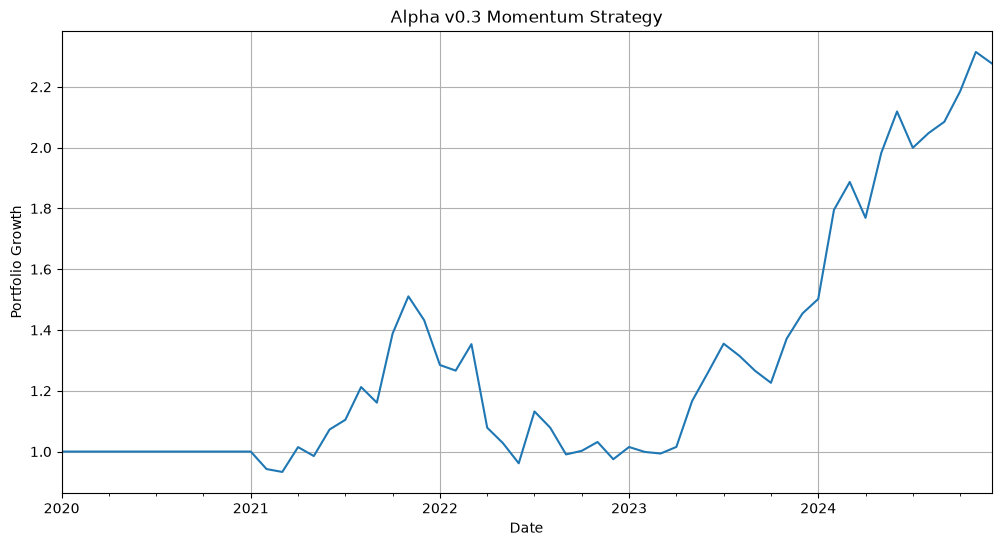

In [13]:
# =====================================================
# RESULTS
# =====================================================

print("\nLatest Momentum Ranking")

display(latest_rank)

print("\nPortfolio Performance")

display(portfolio_growth.tail())

plot_portfolio(portfolio_growth)